### Vijay Hanumandla
### 23102C071
### CMPN - C , Batch - 03
### AML EXP NO 05 : Search and Optimization

In [1]:
!pip install scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.5 MB/s eta 0:00:00


Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from skopt import BayesSearchCV
from skopt.space import Real

Load the dataset

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("\nTarget classes:")
print(data.target_names)

print("\nFirst 5 rows:")
display(X.head())

Dataset shape: (569, 30)

Target classes:
['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Check the dataset

In [4]:
print("Missing values:")
print(X.isnull().sum().sum())

print("\nClass distribution:")
print(y.value_counts())

print("\nDataset information:")
print(X.info())

Missing values:
0

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error       

Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


Create SVM Pipeline

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC())])

Define Cross-Validation

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

GRID SEARCH

Define Grid Search

In [8]:
param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100],
    "svm__gamma": [0.0001, 0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

Run Grid Search

In [9]:
start_time = time.time()

grid_search.fit(X_train, y_train)

grid_time = time.time() - start_time

print("Grid Search completed!")
print("Time taken: {:.2f} seconds".format(grid_time))

Grid Search completed!
Time taken: 5.74 seconds


Display Grid Search Results

In [10]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'svm__C': 10, 'svm__gamma': 0.01}

Best Cross-Validation Accuracy:
0.9758241758241759


Evaluate Grid Search on Test Data

In [11]:
grid_pred = grid_search.predict(X_test)

grid_accuracy = accuracy_score(y_test, grid_pred)

print("Grid Search Test Accuracy:",
      round(grid_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, grid_pred))

Grid Search Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Grid Search Visualization

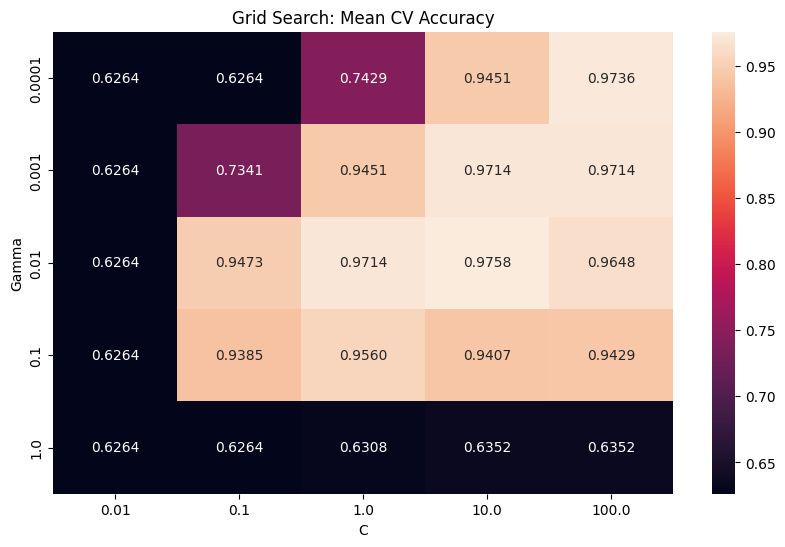

In [12]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_pivot = grid_results.pivot(
    index="param_svm__gamma",
    columns="param_svm__C",
    values="mean_test_score"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    grid_pivot,
    annot=True,
    fmt=".4f"
)

plt.title("Grid Search: Mean CV Accuracy")
plt.xlabel("C")
plt.ylabel("Gamma")

plt.show()

RANDOM SEARCH

Define Random Search

In [13]:
param_distributions = {
    "svm__C": np.logspace(-3, 3, 100),
    "svm__gamma": np.logspace(-5, 1, 100)
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

Run Random Search

In [14]:
start_time = time.time()

random_search.fit(X_train, y_train)

random_time = time.time() - start_time

print("Random Search completed!")
print("Time taken: {:.2f} seconds".format(random_time))

Random Search completed!
Time taken: 6.57 seconds


Evaluate Random Search

In [15]:
random_pred = random_search.predict(X_test)

random_accuracy = accuracy_score(
    y_test,
    random_pred
)

print(
    "Random Search Test Accuracy:",
    round(random_accuracy, 4)
)

print("\nClassification Report:")
print(classification_report(y_test, random_pred))

Random Search Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



BAYESIAN OPTIMIZATION

Define Bayesian Search Space

In [16]:
search_space = {
    "svm__C": Real(
        1e-3,
        1e3,
        prior="log-uniform"
    ),

    "svm__gamma": Real(
        1e-5,
        1e1,
        prior="log-uniform"
    )
}

Create Bayesian Optimization

In [17]:
bayes_search = BayesSearchCV(
    estimator=pipeline,
    search_spaces=search_space,
    n_iter=25,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

Run Bayesian Optimization

In [18]:
start_time = time.time()

bayes_search.fit(X_train, y_train)

bayes_time = time.time() - start_time

print("Bayesian Optimization completed!")
print("Time taken: {:.2f} seconds".format(bayes_time))

Bayesian Optimization completed!
Time taken: 22.71 seconds


Get Best C and Gamma

In [19]:
print("Best Parameters:")
print(bayes_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(bayes_search.best_score_)

Best Parameters:
OrderedDict({'svm__C': 369.2061526365804, 'svm__gamma': 0.000134979266414745})

Best Cross-Validation Accuracy:
0.9758241758241759


Evaluate Bayesian Optimization

In [20]:
bayes_pred = bayes_search.predict(X_test)

bayes_accuracy = accuracy_score(
    y_test,
    bayes_pred
)

print(
    "Bayesian Optimization Test Accuracy:",
    round(bayes_accuracy, 4)
)

print("\nClassification Report:")
print(classification_report(y_test, bayes_pred))

Bayesian Optimization Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Confusion Matrix for Best Bayesian Model

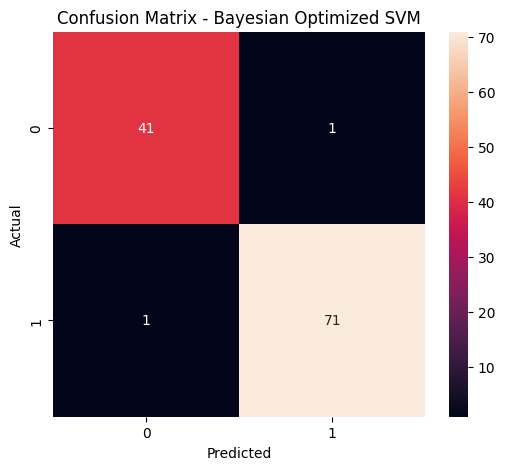

In [21]:
cm = confusion_matrix(y_test, bayes_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix - Bayesian Optimized SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Visualize Bayesian Optimization

In [22]:
bayes_results = pd.DataFrame(
    bayes_search.cv_results_
)

bayes_results = bayes_results.sort_values(
    "rank_test_score"
)

display(
    bayes_results[
        [
            "param_svm__C",
            "param_svm__gamma",
            "mean_test_score",
            "rank_test_score"
        ]
    ].head(10)
)

,param_svm__C,param_svm__gamma,mean_test_score,rank_test_score
16,369.206153,0.000135,0.975824,1
3,74.881740,0.000107,0.973626,2
12,216.910704,0.000088,0.973626,2
4,62.707668,0.004248,0.973626,2
17,4.573932,0.041139,0.971429,5
24,18.091617,0.000747,0.971429,5
19,263.798527,0.002918,0.969231,7
22,3.430893,0.018703,0.969231,7
20,963.670087,0.018900,0.969231,7
13,87.955924,0.008341,0.967033,10


Bayesian Optimization Convergence Plot

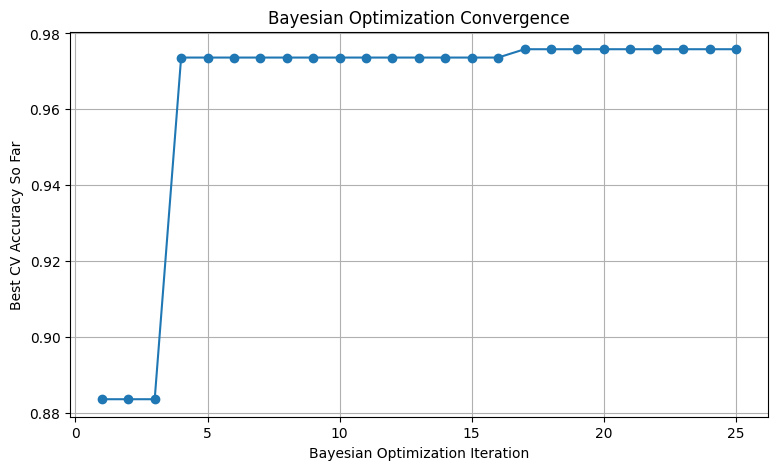

In [23]:
bayes_scores = np.array(
    bayes_search.cv_results_["mean_test_score"]
)

best_so_far = np.maximum.accumulate(
    bayes_scores
)

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(best_so_far) + 1),
    best_so_far,
    marker="o"
)

plt.xlabel("Bayesian Optimization Iteration")
plt.ylabel("Best CV Accuracy So Far")
plt.title("Bayesian Optimization Convergence")

plt.grid(True)

plt.show()

Visualize C vs Gamma

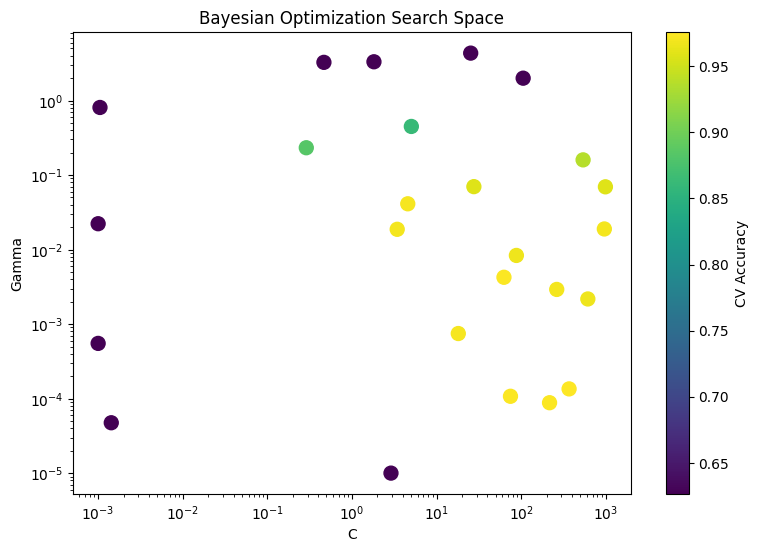

In [24]:
plt.figure(figsize=(9, 6))

plt.scatter(
    bayes_results["param_svm__C"].astype(float),
    bayes_results["param_svm__gamma"].astype(float),
    c=bayes_results["mean_test_score"],
    s=100
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("C")
plt.ylabel("Gamma")

plt.title("Bayesian Optimization Search Space")

plt.colorbar(label="CV Accuracy")

plt.show()

COMPARE ALL THREE METHODS

In [25]:
comparison = pd.DataFrame({
    "Method": [
        "Grid Search",
        "Random Search",
        "Bayesian Optimization"
    ],

    "Best CV Accuracy": [
        grid_search.best_score_,
        random_search.best_score_,
        bayes_search.best_score_
    ],

    "Test Accuracy": [
        grid_accuracy,
        random_accuracy,
        bayes_accuracy
    ],

    "Time (seconds)": [
        grid_time,
        random_time,
        bayes_time
    ]
})

comparison

,Method,Best CV Accuracy,Test Accuracy,Time (seconds)
0,Grid Search,0.975824,0.982456,5.740937
1,Random Search,0.975824,0.982456,6.570903
2,Bayesian Optimization,0.975824,0.982456,22.709293


Comparison Graph

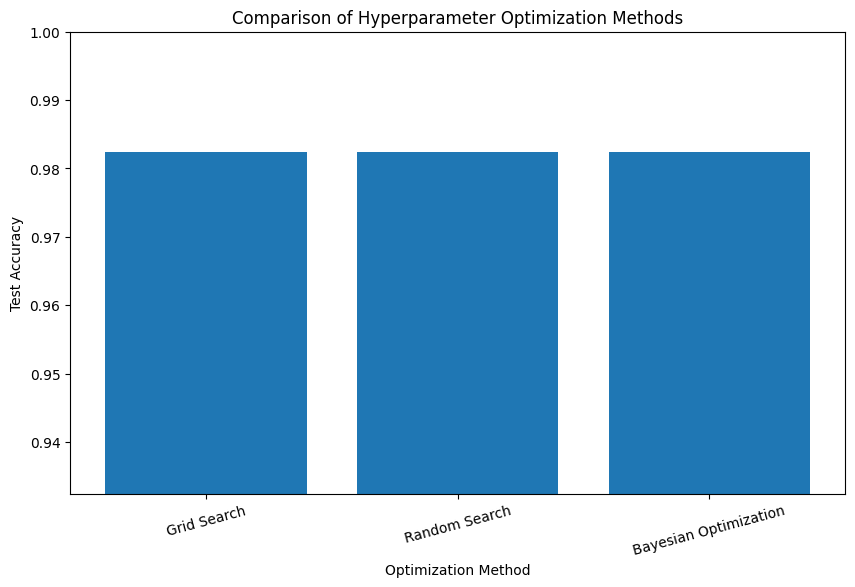

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Method"],
    comparison["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.xlabel("Optimization Method")
plt.title("Comparison of Hyperparameter Optimization Methods")

plt.ylim(
    max(0, comparison["Test Accuracy"].min() - 0.05),
    1.0
)

plt.xticks(rotation=15)

plt.show()

Compare Best C and Gamma

In [27]:
best_parameters = pd.DataFrame({
    "Method": [
        "Grid Search",
        "Random Search",
        "Bayesian Optimization"
    ],

    "Best C": [
        grid_search.best_params_["svm__C"],
        random_search.best_params_["svm__C"],
        bayes_search.best_params_["svm__C"]
    ],

    "Best Gamma": [
        grid_search.best_params_["svm__gamma"],
        random_search.best_params_["svm__gamma"],
        bayes_search.best_params_["svm__gamma"]
    ]
})

best_parameters

,Method,Best C,Best Gamma
0,Grid Search,10.000000,0.010000
1,Random Search,15.199111,0.009326
2,Bayesian Optimization,369.206153,0.000135


Final Best Model

In [28]:
best_method = comparison.loc[
    comparison["Test Accuracy"].idxmax(),
    "Method"
]

best_accuracy = comparison["Test Accuracy"].max()

print("Best Optimization Method:", best_method)
print("Best Test Accuracy:", round(best_accuracy, 4))

Best Optimization Method: Grid Search
Best Test Accuracy: 0.9825


Final Conclusion Output

In [29]:
print("========== EXPERIMENT 5 RESULTS ==========")

print("\nGrid Search")
print("Best C:", grid_search.best_params_["svm__C"])
print("Best Gamma:", grid_search.best_params_["svm__gamma"])
print("CV Accuracy:", round(grid_search.best_score_, 4))
print("Test Accuracy:", round(grid_accuracy, 4))

print("\nRandom Search")
print("Best C:", random_search.best_params_["svm__C"])
print("Best Gamma:", random_search.best_params_["svm__gamma"])
print("CV Accuracy:", round(random_search.best_score_, 4))
print("Test Accuracy:", round(random_accuracy, 4))

print("\nBayesian Optimization")
print("Best C:", bayes_search.best_params_["svm__C"])
print("Best Gamma:", bayes_search.best_params_["svm__gamma"])
print("CV Accuracy:", round(bayes_search.best_score_, 4))
print("Test Accuracy:", round(bayes_accuracy, 4))

print("\n==========================================")

========== EXPERIMENT 5 RESULTS ==========

Grid Search
Best C: 10
Best Gamma: 0.01
CV Accuracy: 0.9758
Test Accuracy: 0.9825

Random Search
Best C: 15.199110829529332
Best Gamma: 0.0093260334688322
CV Accuracy: 0.9758
Test Accuracy: 0.9825

Bayesian Optimization
Best C: 369.2061526365804
Best Gamma: 0.000134979266414745
CV Accuracy: 0.9758
Test Accuracy: 0.9825



Conclusion

Thus, Grid Search, Random Search, and Bayesian Optimization were successfully implemented for tuning the C and gamma hyperparameters of an RBF-based SVM classifier. The optimization methods were visualized and compared based on their model performance and computational time. Bayesian Optimization was able to efficiently explore the hyperparameter space by using information from previous evaluations to identify promising parameter combinations.